# Health Score Analysis - Exploratory Data Analysis

## Purpose
This notebook performs comprehensive EDA to understand and calculate overall account health score based on:
- License utilization patterns
- Customer sentiment and satisfaction
- Support ticket volume and resolution
- Payment history and reliability
- Feature adoption and usage
- Product engagement metrics
- Relationship strength indicators

## Key Metrics Analyzed
- **Health Score** - Overall account health (0-100) - Composite weighted score
- **Utilization Percentage** - License usage (weight: 25%)
- **Sentiment Score** - Customer sentiment (weight: 20%)
- **Support Ticket Volume** - Support issues (weight: 15%)
- **Payment History** - Payment reliability (weight: 15%)
- **Feature Adoption** - Feature usage (weight: 10%)
- **Engagement Score** - Product engagement (weight: 10%)
- **Relationship Score** - Relationship strength (weight: 5%)

## Health Score Formula
```
health_score = (
    utilization_percentage * 0.25 +
    sentiment_score * 0.20 +
    (100 - support_ticket_volume_normalized) * 0.15 +
    payment_history_score * 0.15 +
    feature_adoption_score * 0.10 +
    engagement_score * 0.10 +
    relationship_score * 0.05
)
```

## Health Categories
- **Excellent** (80-100): High utilization, positive sentiment, low support issues
- **Good** (60-79): Moderate utilization, neutral sentiment, manageable support
- **Fair** (40-59): Low utilization, mixed sentiment, some support issues
- **Poor** (20-39): Very low utilization, negative sentiment, frequent support issues
- **Critical** (0-19): Minimal utilization, very negative sentiment, high support volume

In [1]:
# Install required packages
!uv add pandas numpy matplotlib seaborn openpyxl scikit-learn

Resolved 54 packages in 1ms
Audited 47 packages in 4ms


In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime, timedelta
import warnings

warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load and Explore Data

In [3]:
# Load the dataset
# Try multiple possible paths
possible_paths = [
    Path("../../customer_data_25000.xlsx"),
    Path("../customer_data_25000.xlsx"),
    Path("customer_data_25000.xlsx"),
    Path("D:/Internship/Renewal-Upsell-Advisor/Research/customer_data_25000.xlsx")
]

data_path = None
for path in possible_paths:
    if path.exists():
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError("Could not find customer_data_25000.xlsx. Please check the file path.")

df = pd.read_excel(data_path, sheet_name="Accounts")

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn Names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\nFirst few rows:")
df.head()

Dataset loaded successfully!
Shape: 24,874 rows × 27 columns

Column Names:
   1. name
   2. domain
   3. industry
   4. company_size
   5. arr
   6. mrr
   7. contract_start_date
   8. contract_end_date
   9. renewal_date
  10. last_contact_date
  11. status
  12. renewal_stage
  13. health_score
  14. risk_score
  15. relationship_score
  16. churn_probability
  17. sentiment_score
  18. sentiment_category
  19. licenses_total
  20. licenses_used
  21. utilization_percentage
  22. csm_name
  23. csm_email
  24. primary_contact_name
  25. primary_contact_email
  26. primary_contact_phone
  27. salesforce_id

First few rows:


,name,domain,industry,company_size,arr,mrr,contract_start_date,contract_end_date,renewal_date,last_contact_date,...,sentiment_category,licenses_total,licenses_used,utilization_percentage,csm_name,csm_email,primary_contact_name,primary_contact_email,primary_contact_phone,salesforce_id
0,Cole LLC,colellc.com,Technology,Small,156049,13004.08,2025-06-05,2026-06-05,2026-06-05,2026-02-13 16:43:27,...,neutral,20,15,79,Sarah Chen,sarah.chen@company.com,Danielle Johnson,john21@example.net,001-581-896-0013x3890,NaN
1,"Stevens, Martinez and Nielsen",stevensmartinezandnielsen.com,Healthcare,Medium,517493,43124.42,2025-05-19,2026-05-19,2026-05-19,2026-02-04 16:43:27,...,positive,30,23,79,Maria Lopez,maria.lopez@company.com,Lisa Smith,helenpeterson@example.org,651.216.1559,NaN
2,Clark-Adams,clark-adams.com,Analytics,Large,64898,5408.17,2025-04-28,2026-04-28,2026-04-28,2026-02-12 16:43:27,...,negative,20,14,73,Emily Rodriguez,emily.rodriguez@company.com,Christian Carter,barbara10@example.net,441.731.6475,SF-748564
3,"Porter, Wilkerson and Day",porterwilkersonandday.com,Healthcare,Medium,43003,3583.58,2025-05-01,2026-05-01,2026-05-01,2026-02-06 16:43:27,...,neutral,20,14,73,David Kim,david.kim@company.com,Sharon Wong,amandasanchez@example.com,(748)535-0305x6413,SF-319684
4,Carlson-Mcdonald,carlson-mcdonald.com,Enterprise,Medium,100005,8333.75,2025-06-09,2026-06-09,2026-06-09,2026-01-19 16:43:27,...,very_positive,50,33,66,Sarah Chen,sarah.chen@company.com,Douglas Taylor,julie69@example.com,(332)887-1012x269,SF-944151


In [4]:
# Check for health score related columns
health_related_cols = [
    'health_score', 'utilization_percentage', 'sentiment_score',
    'support_ticket_volume', 'support_ticket_count', 'payment_history',
    'feature_adoption', 'engagement_score', 'relationship_score'
]

print("=" * 80)
print("HEALTH SCORE FEATURE AVAILABILITY")
print("=" * 80)

available_cols = []
missing_cols = []

for col in health_related_cols:
    if col in df.columns:
        available_cols.append(col)
        print(f"✓ {col}: Available")
    else:
        missing_cols.append(col)
        print(f"✗ {col}: Missing")

print(f"\nAvailable: {len(available_cols)}/{len(health_related_cols)} features")
print(f"Missing: {len(missing_cols)} features")

# Show basic info about available columns
if available_cols:
    print(f"\n{'='*80}")
    print("AVAILABLE FEATURES - BASIC STATISTICS")
    print(f"{'='*80}")
    print(df[available_cols].describe())

HEALTH SCORE FEATURE AVAILABILITY
✓ health_score: Available
✓ utilization_percentage: Available
✓ sentiment_score: Available
✗ support_ticket_volume: Missing
✗ support_ticket_count: Missing
✗ payment_history: Missing
✗ feature_adoption: Missing
✗ engagement_score: Missing
✓ relationship_score: Available

Available: 4/9 features
Missing: 5 features

AVAILABLE FEATURES - BASIC STATISTICS
       health_score  utilization_percentage  sentiment_score  \
count  24874.000000            24874.000000     24874.000000   
mean      70.217778               59.956260         0.390492   
std       17.780470               20.503779         0.438628   
min       30.000000               25.000000        -0.999400   
25%       58.000000               42.000000         0.098725   
50%       72.000000               60.000000         0.477550   
75%       83.000000               78.000000         0.738200   
max      100.000000               95.000000         0.999900   

       relationship_score  
count 

## 2. Feature Engineering for Health Score Components

In [5]:
# Create a copy for feature engineering
df_health = df.copy()

print("=" * 80)
print("FEATURE ENGINEERING FOR HEALTH SCORE COMPONENTS")
print("=" * 80)

# 1. Utilization Percentage (weight: 25%)
if 'utilization_percentage' not in df_health.columns:
    # Try to calculate from licenses_used and licenses_total
    if 'licenses_used' in df_health.columns and 'licenses_total' in df_health.columns:
        df_health['utilization_percentage'] = (
            (df_health['licenses_used'] / df_health['licenses_total'].replace(0, np.nan)) * 100
        ).clip(0, 100)
        print("✓ Created utilization_percentage from licenses_used/licenses_total")
    else:
        print("⚠️  Cannot calculate utilization_percentage - missing license columns")
        df_health['utilization_percentage'] = np.nan
else:
    print("✓ utilization_percentage already exists")

# 2. Sentiment Score (weight: 20%)
if 'sentiment_score' not in df_health.columns:
    print("⚠️  sentiment_score not found - will need to be created or imputed")
    df_health['sentiment_score'] = np.nan
else:
    print("✓ sentiment_score already exists")

# 3. Support Ticket Volume (weight: 15%)
if 'support_ticket_volume' not in df_health.columns:
    # Try alternative column names
    if 'support_ticket_count' in df_health.columns:
        df_health['support_ticket_volume'] = df_health['support_ticket_count']
        print("✓ Created support_ticket_volume from support_ticket_count")
    elif 'ticket_count' in df_health.columns:
        df_health['support_ticket_volume'] = df_health['ticket_count']
        print("✓ Created support_ticket_volume from ticket_count")
    else:
        print("⚠️  Cannot calculate support_ticket_volume - missing ticket columns")
        df_health['support_ticket_volume'] = 0
else:
    print("✓ support_ticket_volume already exists")

# Normalize support ticket volume (inverse - lower is better)
if 'support_ticket_volume' in df_health.columns:
    max_tickets = df_health['support_ticket_volume'].max()
    if max_tickets > 0:
        df_health['support_ticket_score'] = 100 - (
            (df_health['support_ticket_volume'] / max_tickets) * 100
        ).clip(0, 100)
    else:
        df_health['support_ticket_score'] = 100
    print("✓ Created support_ticket_score (normalized, inverse)")

# 4. Payment History Score (weight: 15%)
if 'payment_history' not in df_health.columns:
    # Try to infer from payment-related columns
    payment_cols = [col for col in df_health.columns if 'payment' in col.lower() or 'paid' in col.lower()]
    if payment_cols:
        print(f"⚠️  payment_history not found, but found related columns: {payment_cols}")
        # Create a simple payment score if we have payment status
        if 'payment_status' in df_health.columns:
            payment_map = {'paid': 100, 'pending': 50, 'overdue': 0, 'failed': 0}
            df_health['payment_history'] = df_health['payment_status'].map(payment_map).fillna(50)
            print("✓ Created payment_history from payment_status")
        else:
            df_health['payment_history'] = 75  # Default neutral score
            print("⚠️  Created default payment_history (75)")
    else:
        df_health['payment_history'] = 75  # Default neutral score
        print("⚠️  Created default payment_history (75)")
else:
    print("✓ payment_history already exists")

# 5. Feature Adoption Score (weight: 10%)
if 'feature_adoption' not in df_health.columns:
    # Try to calculate from feature usage
    feature_cols = [col for col in df_health.columns if 'feature' in col.lower()]
    if feature_cols:
        print(f"⚠️  feature_adoption not found, but found related columns: {feature_cols}")
        # If we have feature usage data, calculate adoption rate
        if 'features_used' in df_health.columns and 'features_available' in df_health.columns:
            df_health['feature_adoption'] = (
                (df_health['features_used'] / df_health['features_available'].replace(0, np.nan)) * 100
            ).clip(0, 100)
            print("✓ Created feature_adoption from features_used/features_available")
        else:
            df_health['feature_adoption'] = 50  # Default moderate adoption
            print("⚠️  Created default feature_adoption (50)")
    else:
        df_health['feature_adoption'] = 50  # Default moderate adoption
        print("⚠️  Created default feature_adoption (50)")
else:
    print("✓ feature_adoption already exists")

# 6. Engagement Score (weight: 10%)
if 'engagement_score' not in df_health.columns:
    # Calculate from sentiment and recency
    if 'sentiment_score' in df_health.columns and 'last_contact_date' in df_health.columns:
        # Convert last_contact_date to datetime
        df_health['last_contact_date'] = pd.to_datetime(df_health['last_contact_date'], errors='coerce')
        today = pd.Timestamp.now()
        df_health['days_since_last_contact'] = (today - df_health['last_contact_date']).dt.days
        
        # Normalize sentiment (0-1)
        sentiment_norm = (df_health['sentiment_score'] - df_health['sentiment_score'].min()) / (
            df_health['sentiment_score'].max() - df_health['sentiment_score'].min() + 1e-6
        )
        
        # Normalize recency (recent = higher score)
        max_days = df_health['days_since_last_contact'].max()
        recency_norm = 1 - (df_health['days_since_last_contact'] / (max_days + 1e-6))
        recency_norm = recency_norm.clip(0, 1)
        
        df_health['engagement_score'] = (sentiment_norm * 0.6 + recency_norm * 0.4) * 100
        print("✓ Created engagement_score from sentiment_score and last_contact_date")
    else:
        df_health['engagement_score'] = 50  # Default moderate engagement
        print("⚠️  Created default engagement_score (50)")
else:
    print("✓ engagement_score already exists")

# 7. Relationship Score (weight: 5%)
if 'relationship_score' not in df_health.columns:
    print("⚠️  relationship_score not found - will use default or calculate from other metrics")
    # Could calculate from contract duration, interaction frequency, etc.
    if 'contract_start_date' in df_health.columns:
        df_health['contract_start_date'] = pd.to_datetime(df_health['contract_start_date'], errors='coerce')
        today = pd.Timestamp.now()
        df_health['relationship_age_days'] = (today - df_health['contract_start_date']).dt.days
        
        # Simple relationship score based on age (normalized)
        max_age = df_health['relationship_age_days'].max()
        if max_age > 0:
            df_health['relationship_score'] = (
                (df_health['relationship_age_days'] / max_age) * 100
            ).clip(0, 100)
            print("✓ Created relationship_score from contract_start_date")
        else:
            df_health['relationship_score'] = 50
            print("⚠️  Created default relationship_score (50)")
    else:
        df_health['relationship_score'] = 50  # Default moderate relationship
        print("⚠️  Created default relationship_score (50)")
else:
    print("✓ relationship_score already exists")

print(f"\n{'='*80}")
print("FEATURE ENGINEERING COMPLETE")
print(f"{'='*80}")

FEATURE ENGINEERING FOR HEALTH SCORE COMPONENTS
✓ utilization_percentage already exists
✓ sentiment_score already exists
⚠️  Cannot calculate support_ticket_volume - missing ticket columns
✓ Created support_ticket_score (normalized, inverse)
⚠️  Created default payment_history (75)
⚠️  Created default feature_adoption (50)
✓ Created engagement_score from sentiment_score and last_contact_date
✓ relationship_score already exists

FEATURE ENGINEERING COMPLETE


In [6]:
# Calculate Health Score using weighted formula
print("=" * 80)
print("CALCULATING HEALTH SCORE")
print("=" * 80)

# Ensure all components are in 0-100 range
health_components = {
    'utilization_percentage': 0.25,
    'sentiment_score': 0.20,
    'support_ticket_score': 0.15,  # Use normalized inverse score
    'payment_history': 0.15,
    'feature_adoption': 0.10,
    'engagement_score': 0.10,
    'relationship_score': 0.05
}

# Check which components are available
available_components = {}
for component, weight in health_components.items():
    if component in df_health.columns:
        # Clip to 0-100 range
        df_health[component] = df_health[component].clip(0, 100)
        available_components[component] = weight
        print(f"✓ {component}: Available (weight: {weight*100:.0f}%)")
    else:
        print(f"✗ {component}: Missing")

# Calculate health score
df_health['health_score_calculated'] = 0
total_weight = 0

for component, weight in available_components.items():
    # Fill missing values with median
    median_val = df_health[component].median()
    df_health[component] = df_health[component].fillna(median_val)
    
    # Add weighted component
    df_health['health_score_calculated'] += df_health[component] * weight
    total_weight += weight

# Normalize if weights don't sum to 1
if total_weight > 0:
    df_health['health_score_calculated'] = df_health['health_score_calculated'] / total_weight
    df_health['health_score_calculated'] = df_health['health_score_calculated'].clip(0, 100)

print(f"\n✓ Health Score calculated using {len(available_components)} components")
print(f"  Total weight: {total_weight:.2f}")

# If original health_score exists, compare
if 'health_score' in df_health.columns:
    print(f"\n{'='*80}")
    print("COMPARING CALCULATED vs EXISTING HEALTH SCORE")
    print(f"{'='*80}")
    comparison = pd.DataFrame({
        'Calculated': df_health['health_score_calculated'].describe(),
        'Existing': df_health['health_score'].describe()
    })
    print(comparison)
    
    # Correlation
    corr = df_health[['health_score_calculated', 'health_score']].corr().iloc[0, 1]
    print(f"\nCorrelation between calculated and existing: {corr:.4f}")
else:
    # Use calculated score as the main health score
    df_health['health_score'] = df_health['health_score_calculated']
    print("\n✓ Using calculated health_score as primary score")

# Create health categories
def categorize_health(score):
    if pd.isna(score):
        return 'unknown'
    elif score >= 80:
        return 'excellent'
    elif score >= 60:
        return 'good'
    elif score >= 40:
        return 'fair'
    elif score >= 20:
        return 'poor'
    else:
        return 'critical'

df_health['health_category'] = df_health['health_score'].apply(categorize_health)

# Create health trend (simplified - would need historical data for real trend)
# For now, use relationship with other metrics
if 'sentiment_score' in df_health.columns and 'utilization_percentage' in df_health.columns:
    # Simple trend based on sentiment and utilization
    df_health['health_trend'] = 'stable'
    df_health.loc[
        (df_health['sentiment_score'] > df_health['sentiment_score'].median()) &
        (df_health['utilization_percentage'] > df_health['utilization_percentage'].median()),
        'health_trend'
    ] = 'improving'
    df_health.loc[
        (df_health['sentiment_score'] < df_health['sentiment_score'].median()) &
        (df_health['utilization_percentage'] < df_health['utilization_percentage'].median()),
        'health_trend'
    ] = 'declining'
else:
    df_health['health_trend'] = 'stable'

print(f"\n{'='*80}")
print("HEALTH SCORE SUMMARY")
print(f"{'='*80}")
print(f"Mean Health Score: {df_health['health_score'].mean():.2f}")
print(f"Median Health Score: {df_health['health_score'].median():.2f}")
print(f"Std Health Score: {df_health['health_score'].std():.2f}")
print(f"\nHealth Score Distribution:")
print(df_health['health_category'].value_counts().sort_index())
print(f"\nHealth Trend Distribution:")
print(df_health['health_trend'].value_counts())

CALCULATING HEALTH SCORE
✓ utilization_percentage: Available (weight: 25%)
✓ sentiment_score: Available (weight: 20%)
✓ support_ticket_score: Available (weight: 15%)
✓ payment_history: Available (weight: 15%)
✓ feature_adoption: Available (weight: 10%)
✓ engagement_score: Available (weight: 10%)
✓ relationship_score: Available (weight: 5%)

✓ Health Score calculated using 7 components
  Total weight: 1.00

COMPARING CALCULATED vs EXISTING HEALTH SCORE
         Calculated      Existing
count  24874.000000  24874.000000
mean      55.946056     70.217778
std        5.665608     17.780470
min       39.604737     30.000000
25%       51.492813     58.000000
50%       55.924879     72.000000
75%       60.439037     83.000000
max       69.754586    100.000000

Correlation between calculated and existing: 0.3125

HEALTH SCORE SUMMARY
Mean Health Score: 70.22
Median Health Score: 72.00
Std Health Score: 17.78

Health Score Distribution:
health_category
excellent    8479
fair         4760
good   

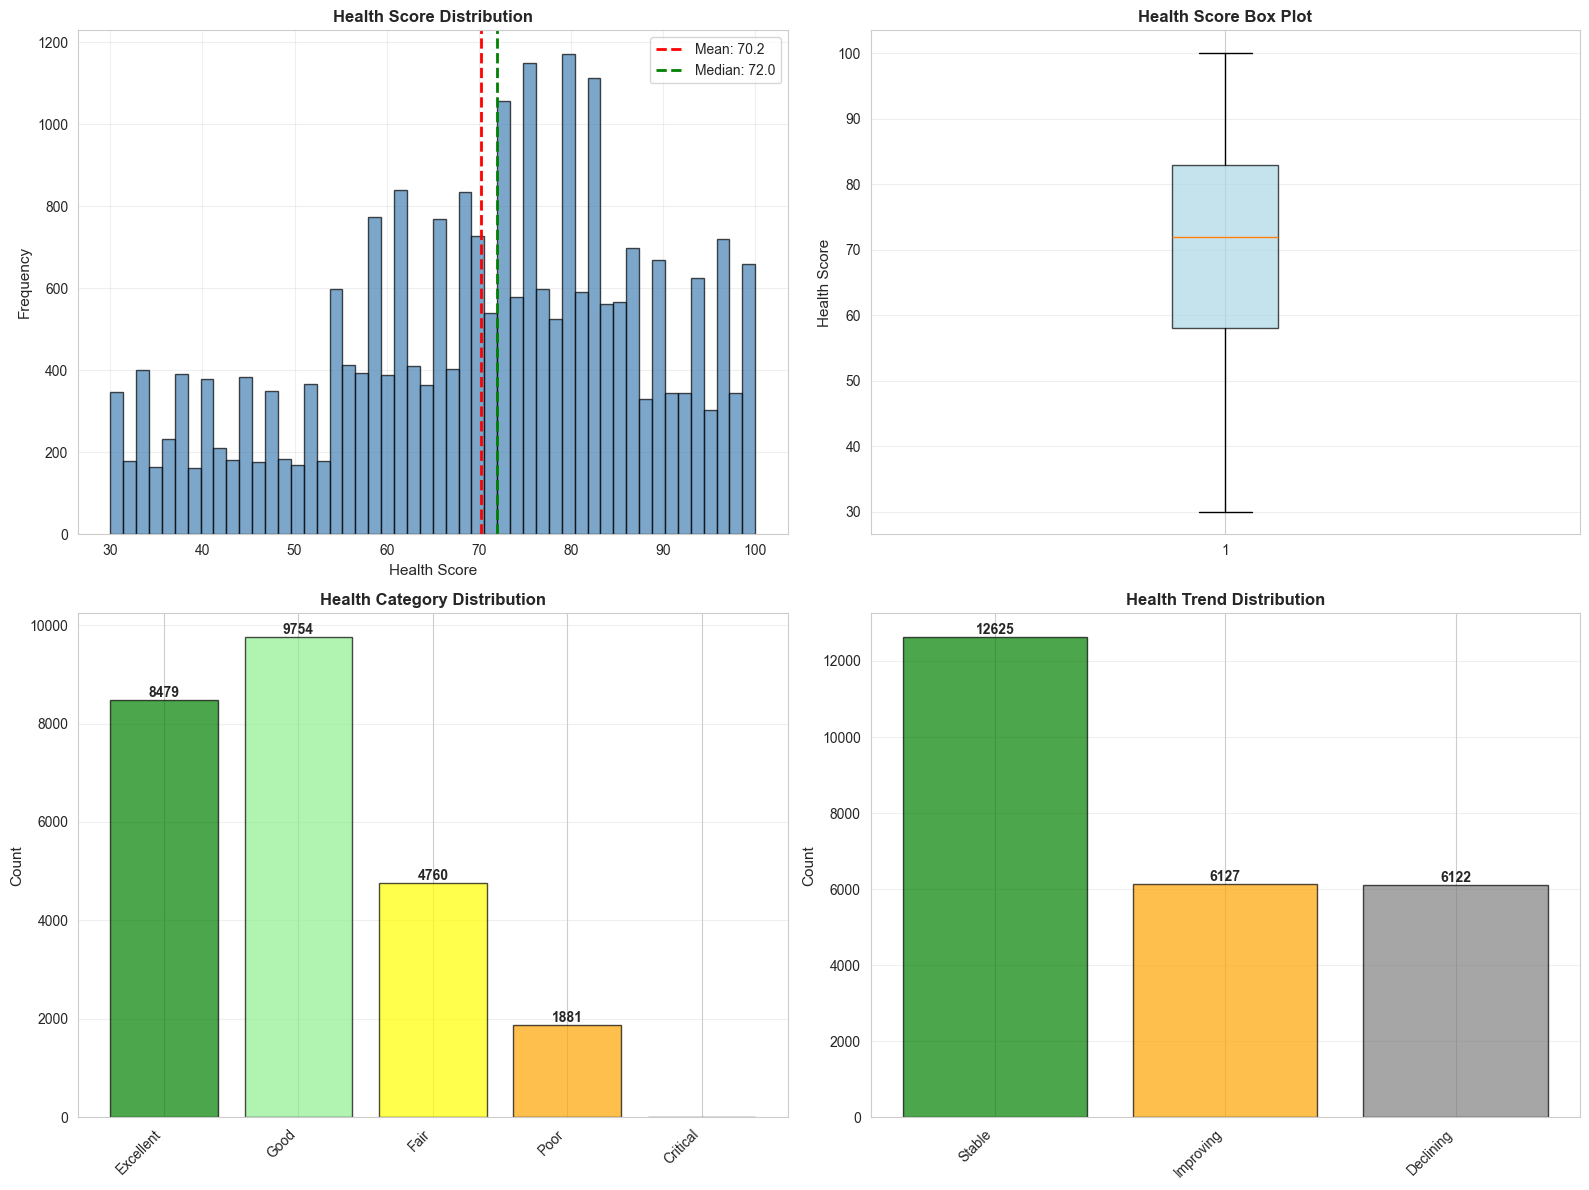

HEALTH SCORE SUMMARY STATISTICS
count    24874.000000
mean        70.217778
std         17.780470
min         30.000000
25%         58.000000
50%         72.000000
75%         83.000000
max        100.000000
Name: health_score, dtype: float64

Health Score by Category:
                 count   mean   std  min  max
health_category                              
excellent         8479  88.71  6.25   80  100
fair              4760  51.11  6.04   40   59
good              9754  70.34  5.67   60   79
poor              1881  34.56  2.80   30   39


In [7]:
# Visualize health score distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Histogram
axes[0, 0].hist(df_health['health_score'].dropna(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df_health['health_score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_health["health_score"].mean():.1f}')
axes[0, 0].axvline(df_health['health_score'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df_health["health_score"].median():.1f}')
axes[0, 0].set_xlabel('Health Score', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Health Score Distribution', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Box plot
axes[0, 1].boxplot(df_health['health_score'].dropna(), vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', alpha=0.7))
axes[0, 1].set_ylabel('Health Score', fontsize=11)
axes[0, 1].set_title('Health Score Box Plot', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Health Category Distribution
health_cat_counts = df_health['health_category'].value_counts()
category_order = ['excellent', 'good', 'fair', 'poor', 'critical']
colors = ['green', 'lightgreen', 'yellow', 'orange', 'red']
axes[1, 0].bar(range(len(category_order)), 
               [health_cat_counts.get(cat, 0) for cat in category_order],
               color=colors, edgecolor='black', alpha=0.7)
axes[1, 0].set_xticks(range(len(category_order)))
axes[1, 0].set_xticklabels([cat.title() for cat in category_order], rotation=45, ha='right')
axes[1, 0].set_ylabel('Count', fontsize=11)
axes[1, 0].set_title('Health Category Distribution', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Add count labels on bars
for i, cat in enumerate(category_order):
    count = health_cat_counts.get(cat, 0)
    if count > 0:
        axes[1, 0].text(i, count, str(count), ha='center', va='bottom', fontweight='bold')

# 4. Health Trend Distribution
trend_counts = df_health['health_trend'].value_counts()
axes[1, 1].bar(range(len(trend_counts)), trend_counts.values,
               color=['green', 'orange', 'gray'], edgecolor='black', alpha=0.7)
axes[1, 1].set_xticks(range(len(trend_counts)))
axes[1, 1].set_xticklabels([trend.title() for trend in trend_counts.index], rotation=45, ha='right')
axes[1, 1].set_ylabel('Count', fontsize=11)
axes[1, 1].set_title('Health Trend Distribution', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Add count labels
for i, (trend, count) in enumerate(trend_counts.items()):
    axes[1, 1].text(i, count, str(count), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Summary statistics
print("=" * 80)
print("HEALTH SCORE SUMMARY STATISTICS")
print("=" * 80)
print(df_health['health_score'].describe())
print(f"\nHealth Score by Category:")
print(df_health.groupby('health_category')['health_score'].agg(['count', 'mean', 'std', 'min', 'max']).round(2))

## 5. Component Analysis - Individual Feature Distributions

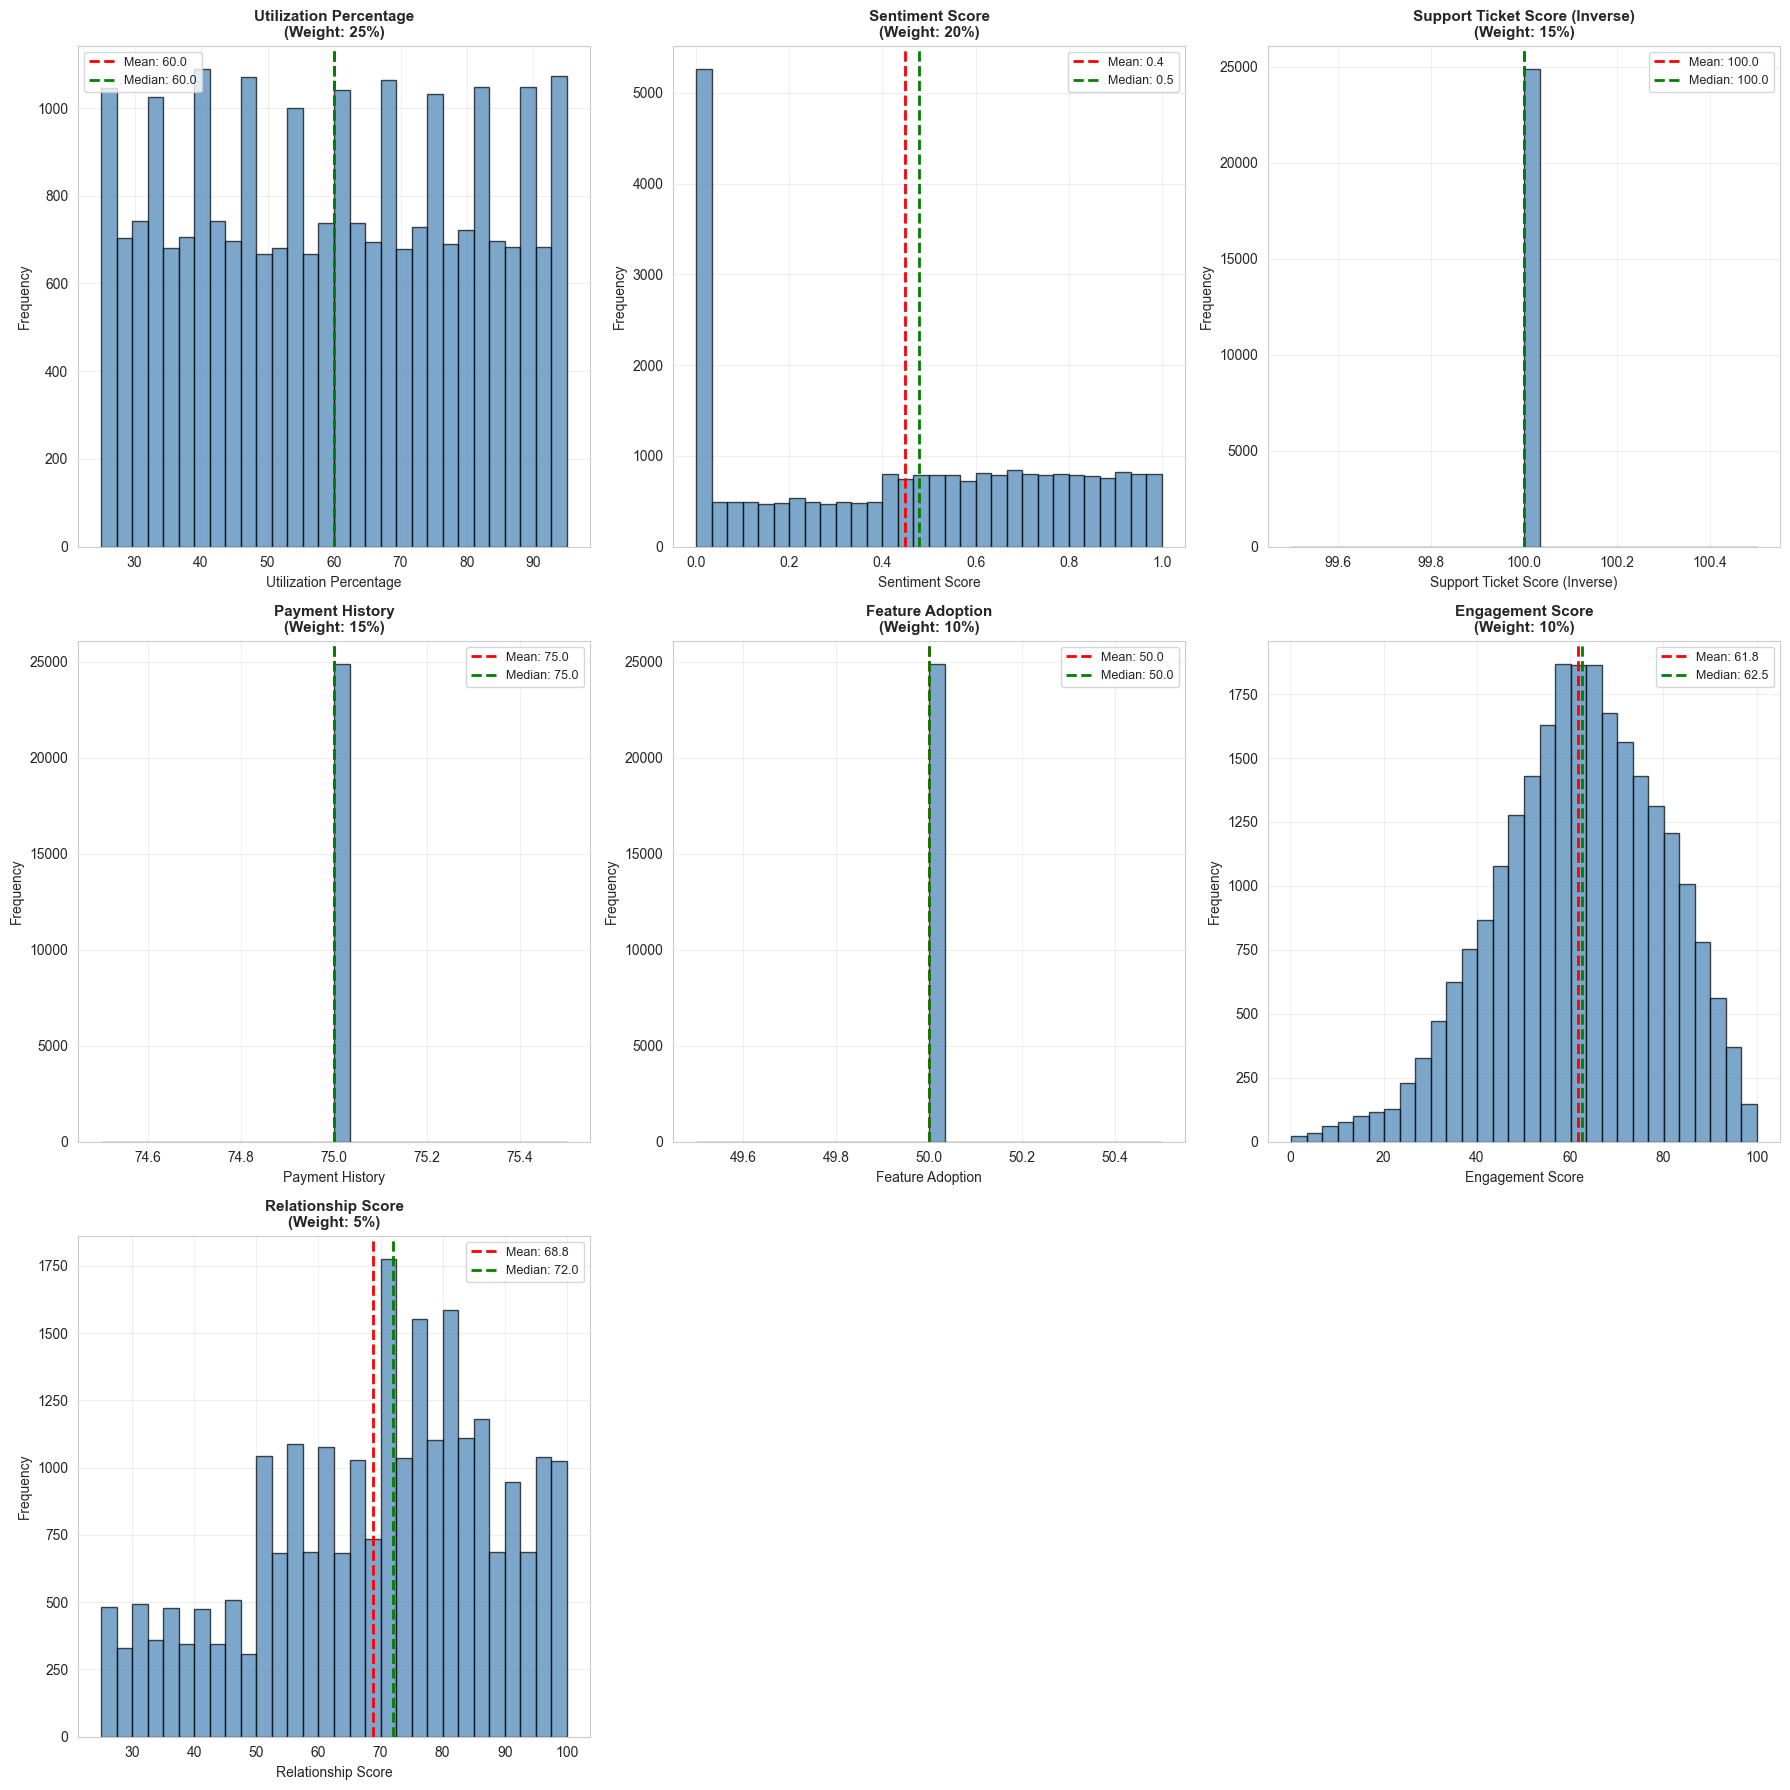

COMPONENT STATISTICS
       utilization_percentage  sentiment_score  support_ticket_score  \
count                24874.00         24874.00               24874.0   
mean                    59.96             0.45                 100.0   
std                     20.50             0.33                   0.0   
min                     25.00             0.00                 100.0   
25%                     42.00             0.10                 100.0   
50%                     60.00             0.48                 100.0   
75%                     78.00             0.74                 100.0   
max                     95.00             1.00                 100.0   

       payment_history  feature_adoption  engagement_score  relationship_score  
count          24874.0           24874.0          24874.00            24874.00  
mean              75.0              50.0             61.76               68.83  
std                0.0               0.0             17.67               19.15  
min   

In [8]:
# Analyze each health score component
components_to_plot = [
    ('utilization_percentage', 'Utilization Percentage', 0.25),
    ('sentiment_score', 'Sentiment Score', 0.20),
    ('support_ticket_score', 'Support Ticket Score (Inverse)', 0.15),
    ('payment_history', 'Payment History', 0.15),
    ('feature_adoption', 'Feature Adoption', 0.10),
    ('engagement_score', 'Engagement Score', 0.10),
    ('relationship_score', 'Relationship Score', 0.05)
]

available_components = [(col, name, weight) for col, name, weight in components_to_plot 
                       if col in df_health.columns]

n_components = len(available_components)
n_cols = 3
n_rows = (n_components + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6*n_rows))
axes = axes.flatten() if n_components > 1 else [axes]

for idx, (col, name, weight) in enumerate(available_components):
    ax = axes[idx]
    
    # Histogram
    data = df_health[col].dropna()
    ax.hist(data, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {data.mean():.1f}')
    ax.axvline(data.median(), color='green', linestyle='--', linewidth=2, 
               label=f'Median: {data.median():.1f}')
    ax.set_xlabel(name, fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.set_title(f'{name}\n(Weight: {weight*100:.0f}%)', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(n_components, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# Component statistics
print("=" * 80)
print("COMPONENT STATISTICS")
print("=" * 80)
component_stats = pd.DataFrame({
    col: df_health[col].describe() 
    for col, _, _ in available_components
})
print(component_stats.round(2))

## 6. Correlation Analysis

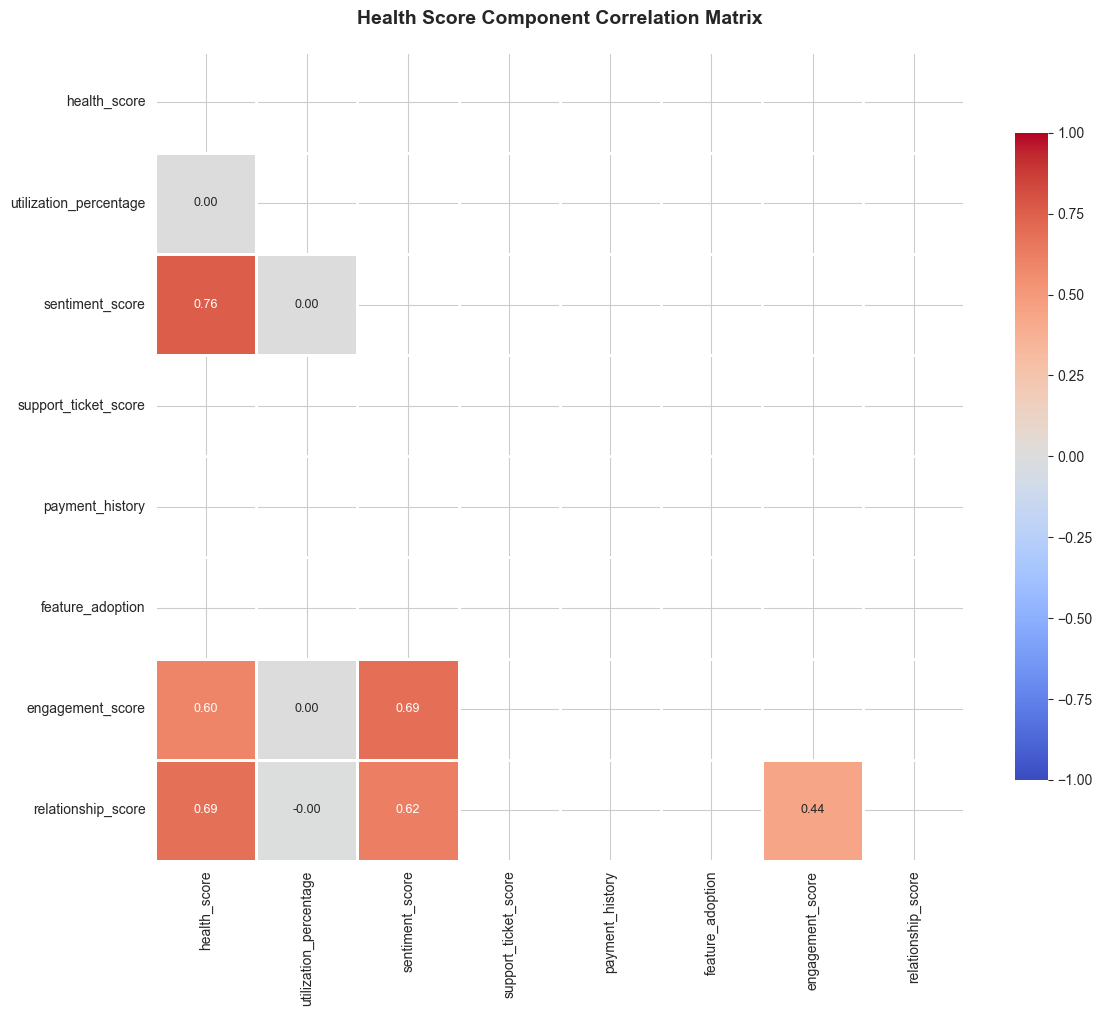

CORRELATION WITH HEALTH SCORE
health_score              1.0000
sentiment_score           0.7590
relationship_score        0.6870
engagement_score          0.5956
utilization_percentage    0.0020
support_ticket_score         NaN
payment_history              NaN
feature_adoption             NaN
Name: health_score, dtype: float64


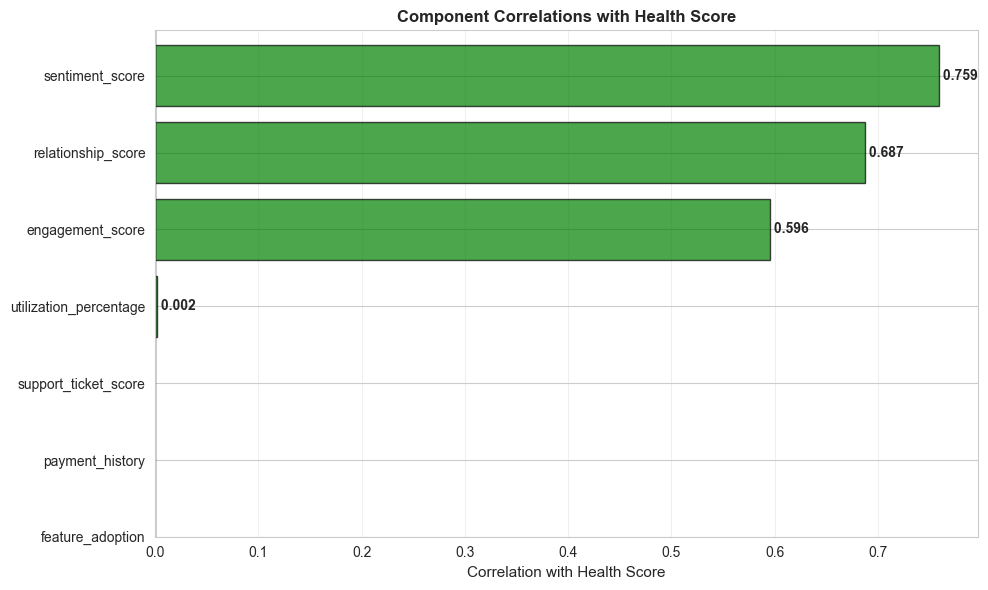

In [9]:
# Correlation matrix for health score components
correlation_cols = ['health_score'] + [col for col, _, _ in available_components]
correlation_data = df_health[correlation_cols].corr()

# Create heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_data, dtype=bool))
sns.heatmap(correlation_data, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, mask=mask,
            vmin=-1, vmax=1, annot_kws={'size': 9})
plt.title('Health Score Component Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Correlation with health score
print("=" * 80)
print("CORRELATION WITH HEALTH SCORE")
print("=" * 80)
health_correlations = correlation_data['health_score'].sort_values(ascending=False)
print(health_correlations.round(4))

# Visualize correlations with health score
fig, ax = plt.subplots(figsize=(10, 6))
health_correlations_plot = health_correlations.drop('health_score')
colors = ['green' if x > 0 else 'red' for x in health_correlations_plot.values]
ax.barh(range(len(health_correlations_plot)), health_correlations_plot.values, 
        color=colors, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(health_correlations_plot)))
ax.set_yticklabels(health_correlations_plot.index)
ax.set_xlabel('Correlation with Health Score', fontsize=11)
ax.set_title('Component Correlations with Health Score', fontsize=12, fontweight='bold')
ax.axvline(0, color='black', linestyle='-', linewidth=1)
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()

# Add correlation values on bars
for i, (idx, val) in enumerate(health_correlations_plot.items()):
    ax.text(val, i, f' {val:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

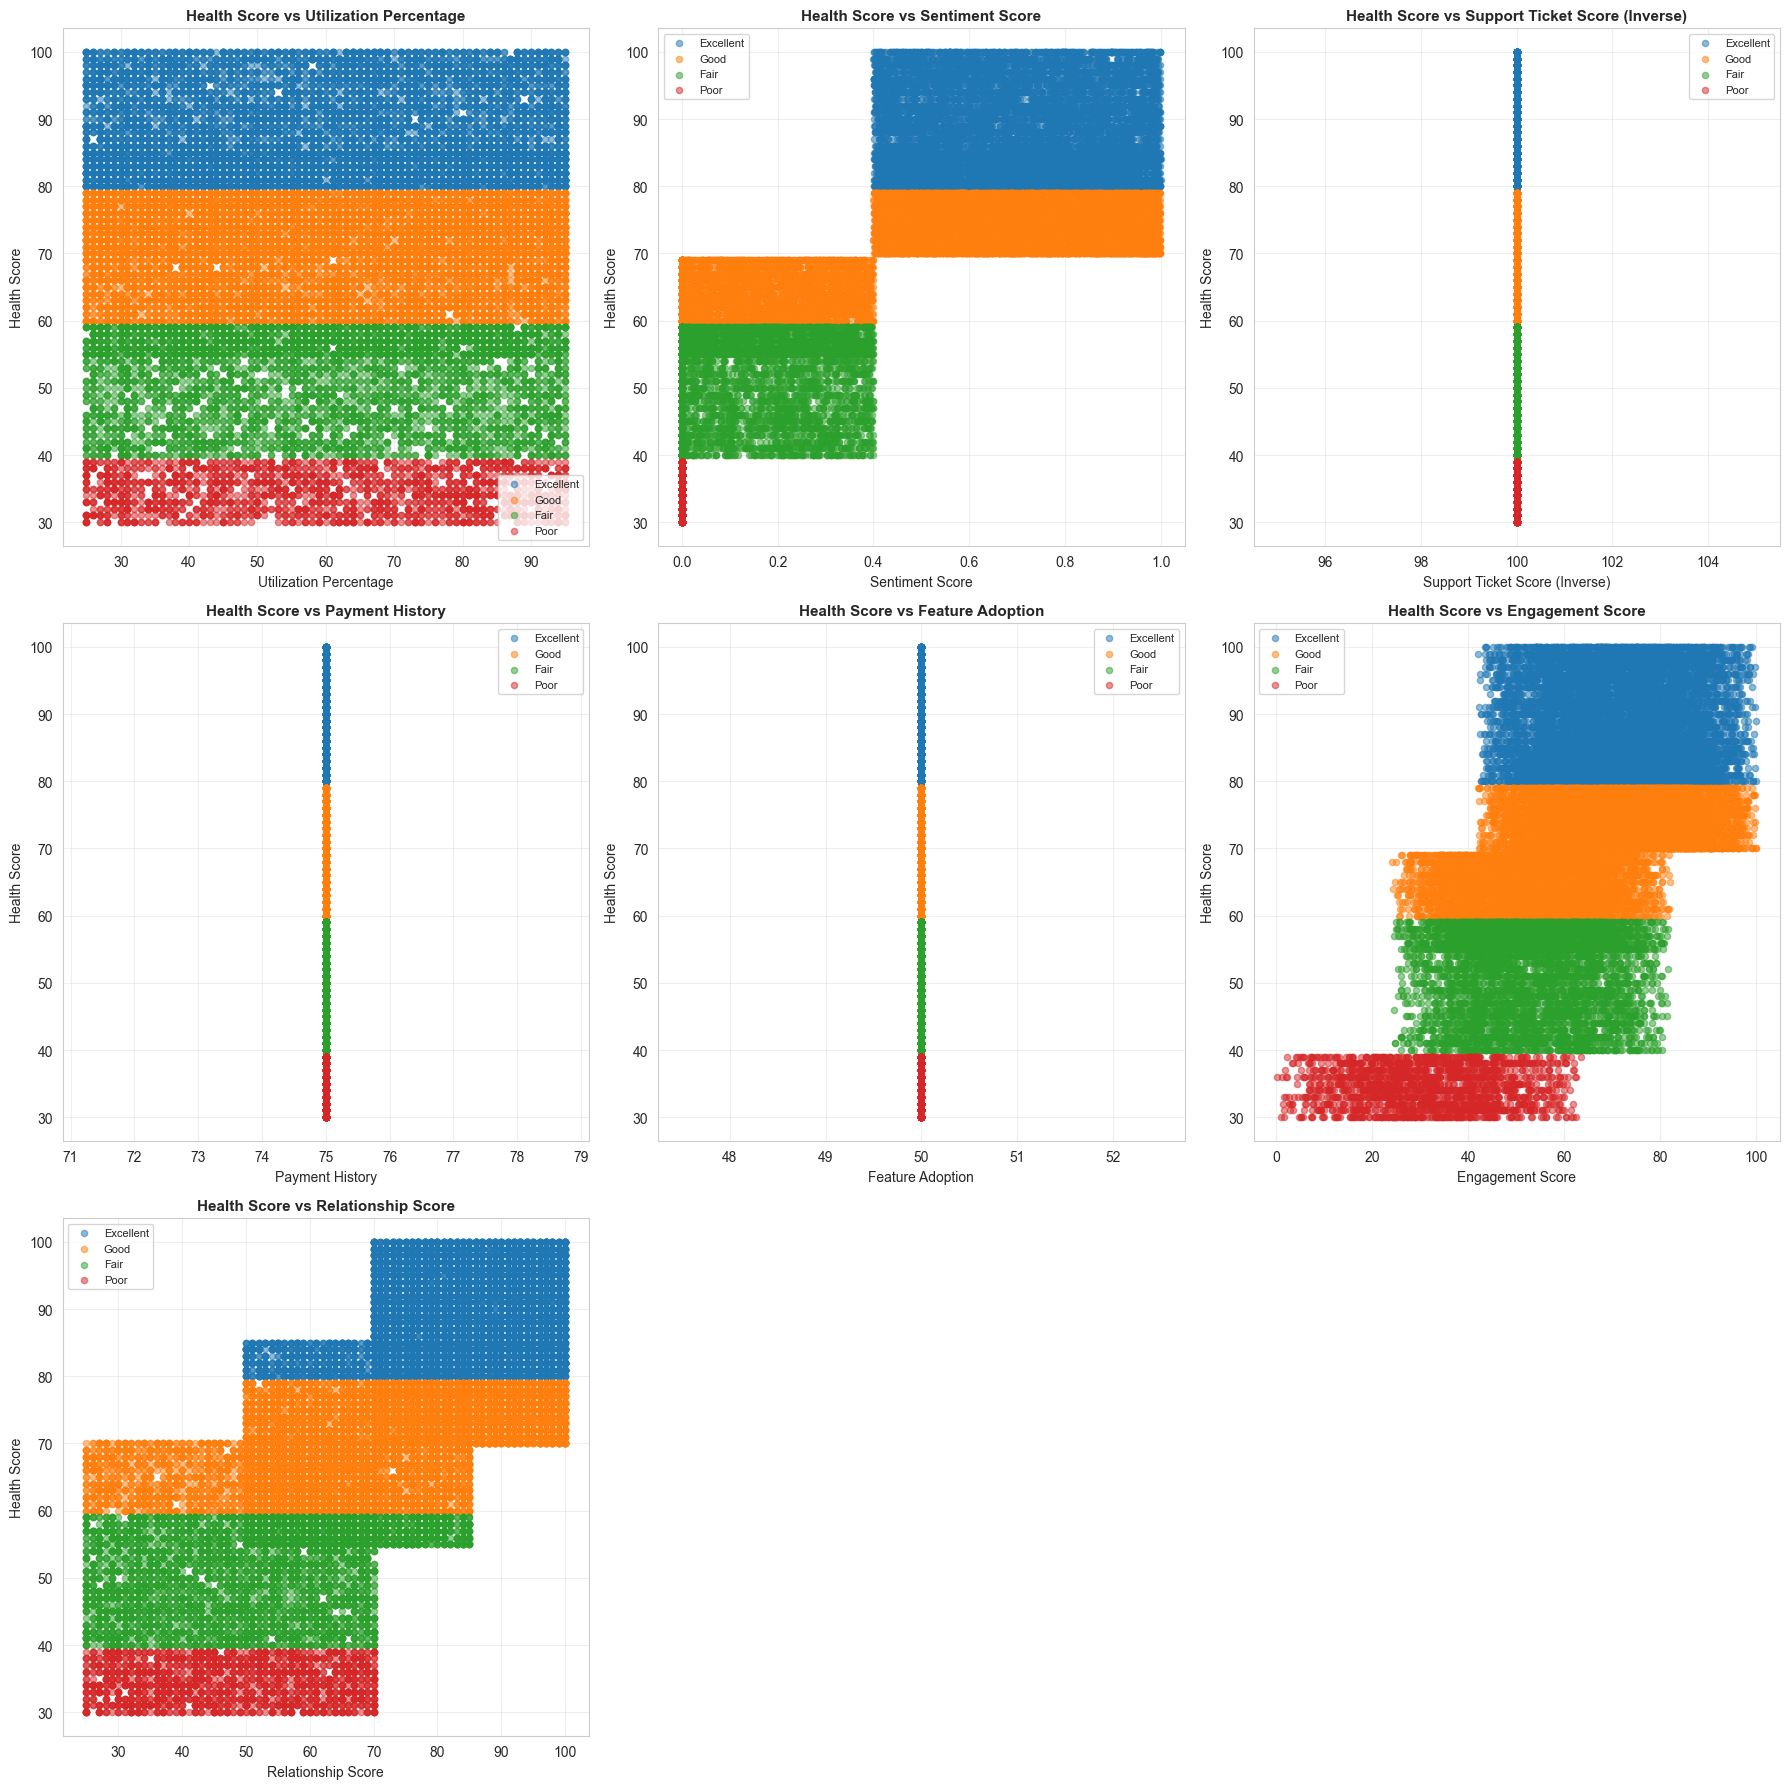

In [10]:
# Scatter plots: Health Score vs each component
n_components = len(available_components)
n_cols = 3
n_rows = (n_components + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6*n_rows))
axes = axes.flatten() if n_components > 1 else [axes]

for idx, (col, name, weight) in enumerate(available_components):
    ax = axes[idx]
    
    # Scatter plot with color by health category
    for category in ['excellent', 'good', 'fair', 'poor', 'critical']:
        mask = df_health['health_category'] == category
        if mask.sum() > 0:
            ax.scatter(df_health.loc[mask, col], df_health.loc[mask, 'health_score'],
                      alpha=0.5, s=20, label=category.title())
    
    ax.set_xlabel(name, fontsize=10)
    ax.set_ylabel('Health Score', fontsize=10)
    ax.set_title(f'Health Score vs {name}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(n_components, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 8. Health Score by Industry and Company Size

HEALTH SCORE BY INDUSTRY
                mean    std  count
industry                          
CleanTech      71.56  17.77   1502
Media          70.98  17.47   1538
Technology     70.63  17.97   1592
Education      70.54  17.87   1538
Enterprise     70.48  17.57   1568
Consulting     70.32  18.02   1550
E-commerce     70.26  17.88   1538
Research       70.21  17.76   1611
Finance        70.20  17.93   1578
SaaS           70.12  17.39   1574
Real Estate    69.95  17.51   1557
Retail         69.94  18.04   1569
Manufacturing  69.94  17.69   1486
Cloud          69.88  17.71   1585
Analytics      69.67  17.64   1613
Healthcare     68.81  18.20   1475

HEALTH SCORE BY COMPANY SIZE
               mean    std  count
company_size                     
Enterprise    70.32  17.70   6059
Small         70.24  17.72   6346
Medium        70.22  17.70   6211
Large         70.10  18.01   6258


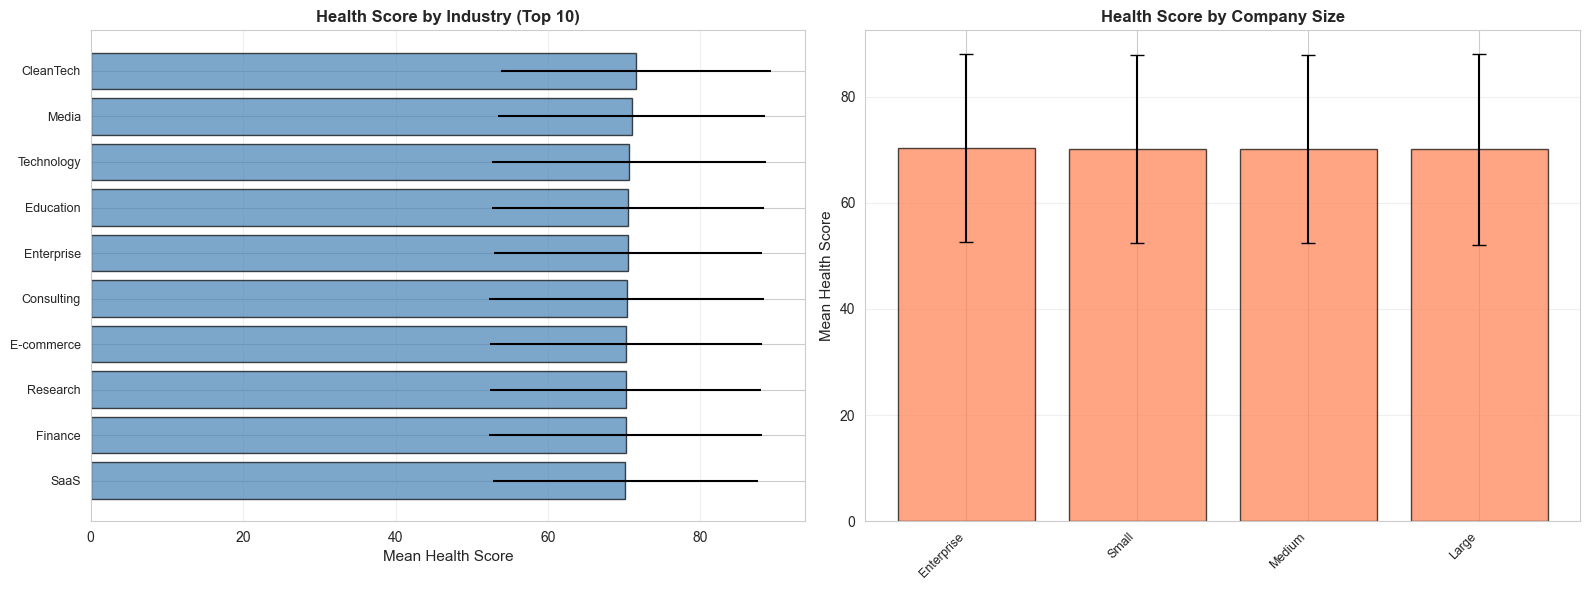

In [11]:
# Analyze health score by industry and company size
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Health Score by Industry
if 'industry' in df_health.columns:
    industry_health = df_health.groupby('industry')['health_score'].agg(['mean', 'std', 'count']).sort_values('mean', ascending=False)
    
    # Plot top 10 industries
    top_industries = industry_health.head(10)
    axes[0].barh(range(len(top_industries)), top_industries['mean'], 
                xerr=top_industries['std'], color='steelblue', alpha=0.7, edgecolor='black')
    axes[0].set_yticks(range(len(top_industries)))
    axes[0].set_yticklabels(top_industries.index, fontsize=9)
    axes[0].set_xlabel('Mean Health Score', fontsize=11)
    axes[0].set_title('Health Score by Industry (Top 10)', fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3, axis='x')
    axes[0].invert_yaxis()
    
    print("=" * 80)
    print("HEALTH SCORE BY INDUSTRY")
    print("=" * 80)
    print(industry_health.round(2))
else:
    axes[0].text(0.5, 0.5, 'Industry column not found', ha='center', va='center', transform=axes[0].transAxes)
    axes[0].set_title('Health Score by Industry', fontsize=12, fontweight='bold')

# Health Score by Company Size
if 'company_size' in df_health.columns:
    size_health = df_health.groupby('company_size')['health_score'].agg(['mean', 'std', 'count']).sort_values('mean', ascending=False)
    
    axes[1].bar(range(len(size_health)), size_health['mean'], 
               yerr=size_health['std'], color='coral', alpha=0.7, edgecolor='black', capsize=5)
    axes[1].set_xticks(range(len(size_health)))
    axes[1].set_xticklabels(size_health.index, rotation=45, ha='right', fontsize=9)
    axes[1].set_ylabel('Mean Health Score', fontsize=11)
    axes[1].set_title('Health Score by Company Size', fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    print(f"\n{'='*80}")
    print("HEALTH SCORE BY COMPANY SIZE")
    print(f"{'='*80}")
    print(size_health.round(2))
else:
    axes[1].text(0.5, 0.5, 'Company Size column not found', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('Health Score by Company Size', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 9. Component Contribution Analysis

COMPONENT CONTRIBUTION ANALYSIS
                                Weight  Avg Component Value  \
Support Ticket Score (Inverse)    0.15               100.00   
Utilization Percentage            0.25                59.96   
Payment History                   0.15                75.00   
Engagement Score                  0.10                61.76   
Feature Adoption                  0.10                50.00   
Relationship Score                0.05                68.83   
Sentiment Score                   0.20                 0.45   

                                Weighted Contribution  Contribution %  
Support Ticket Score (Inverse)                  15.00           21.36  
Utilization Percentage                          14.99           21.35  
Payment History                                 11.25           16.02  
Engagement Score                                 6.18            8.80  
Feature Adoption                                 5.00            7.12  
Relationship Score             

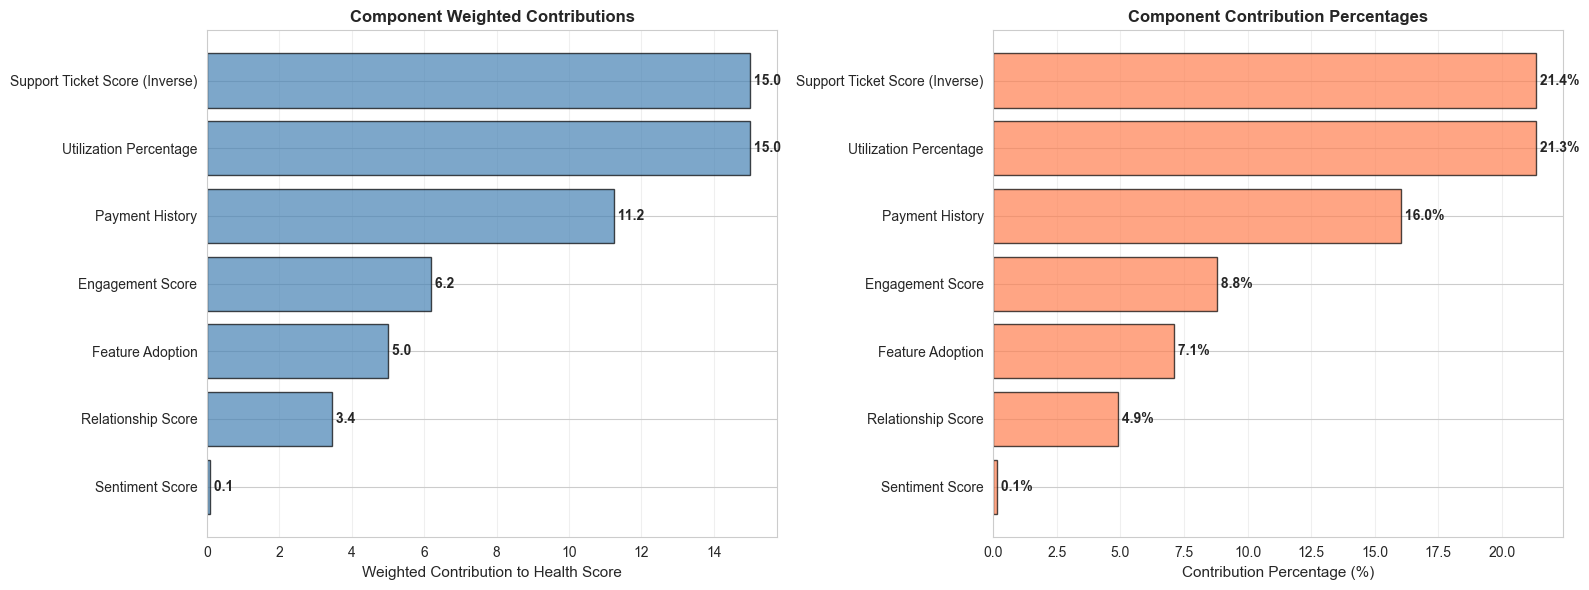

In [12]:
# Analyze how each component contributes to health score
print("=" * 80)
print("COMPONENT CONTRIBUTION ANALYSIS")
print("=" * 80)

# Calculate weighted contribution for each component
component_contributions = {}
for col, name, weight in available_components:
    # Average weighted contribution
    avg_contribution = (df_health[col] * weight).mean()
    component_contributions[name] = {
        'Weight': weight,
        'Avg Component Value': df_health[col].mean(),
        'Weighted Contribution': avg_contribution,
        'Contribution %': (avg_contribution / df_health['health_score'].mean()) * 100
    }

contrib_df = pd.DataFrame(component_contributions).T
contrib_df = contrib_df.sort_values('Weighted Contribution', ascending=False)
print(contrib_df.round(2))

# Visualize component contributions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Weighted contributions
axes[0].barh(range(len(contrib_df)), contrib_df['Weighted Contribution'],
            color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_yticks(range(len(contrib_df)))
axes[0].set_yticklabels(contrib_df.index, fontsize=10)
axes[0].set_xlabel('Weighted Contribution to Health Score', fontsize=11)
axes[0].set_title('Component Weighted Contributions', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')
axes[0].invert_yaxis()

# Add value labels
for i, val in enumerate(contrib_df['Weighted Contribution']):
    axes[0].text(val, i, f' {val:.1f}', va='center', fontweight='bold')

# Contribution percentages
axes[1].barh(range(len(contrib_df)), contrib_df['Contribution %'],
            color='coral', alpha=0.7, edgecolor='black')
axes[1].set_yticks(range(len(contrib_df)))
axes[1].set_yticklabels(contrib_df.index, fontsize=10)
axes[1].set_xlabel('Contribution Percentage (%)', fontsize=11)
axes[1].set_title('Component Contribution Percentages', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')
axes[1].invert_yaxis()

# Add value labels
for i, val in enumerate(contrib_df['Contribution %']):
    axes[1].text(val, i, f' {val:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

Health Score vs Churn Probability Correlation: -0.7420


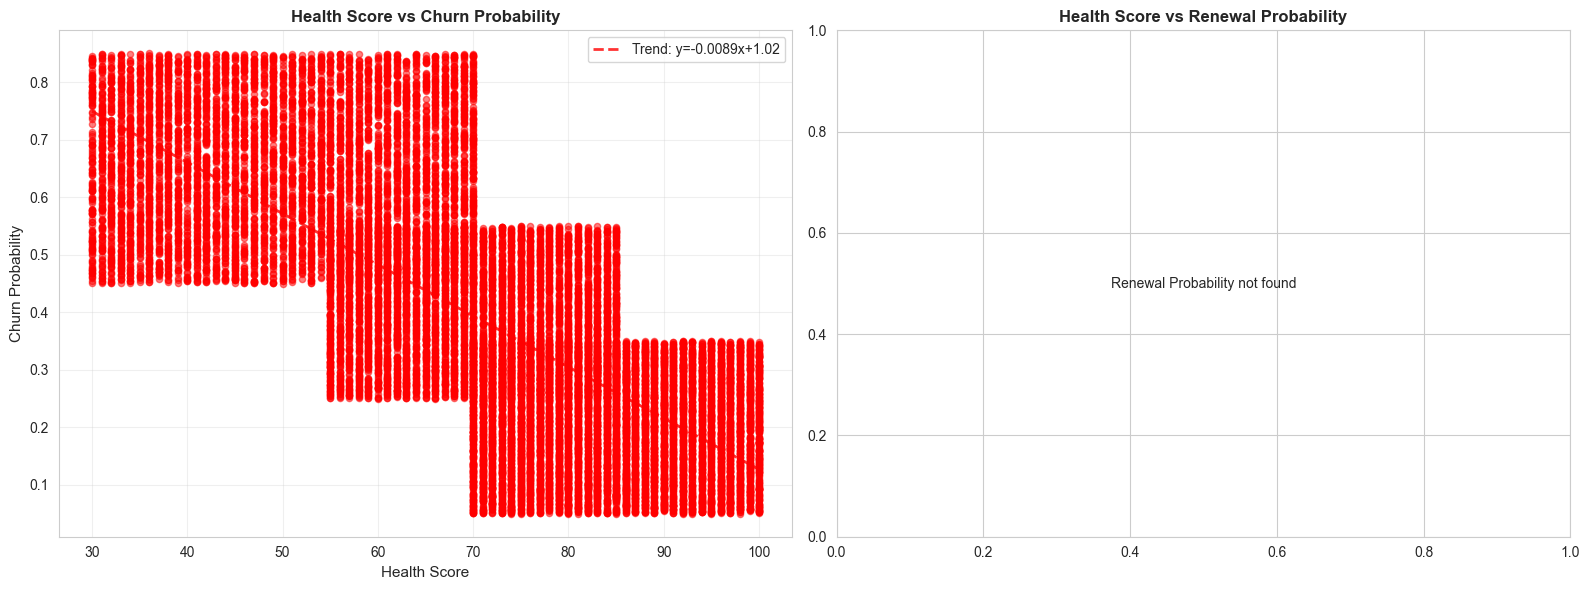


HEALTH SCORE BY CATEGORY - CHURN/RENEWAL ANALYSIS


KeyError: "Label(s) ['renewal_probability'] do not exist"

In [13]:
# Analyze relationship between health score and churn/renewal
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Health Score vs Churn Probability
if 'churn_probability' in df_health.columns:
    axes[0].scatter(df_health['health_score'], df_health['churn_probability'],
                   alpha=0.5, s=20, color='red')
    axes[0].set_xlabel('Health Score', fontsize=11)
    axes[0].set_ylabel('Churn Probability', fontsize=11)
    axes[0].set_title('Health Score vs Churn Probability', fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    # Add trend line
    z = np.polyfit(df_health['health_score'].dropna(), 
                   df_health['churn_probability'].dropna(), 1)
    p = np.poly1d(z)
    axes[0].plot(df_health['health_score'].sort_values(), 
                p(df_health['health_score'].sort_values()), 
                "r--", alpha=0.8, linewidth=2, label=f'Trend: y={z[0]:.4f}x+{z[1]:.2f}')
    axes[0].legend()
    
    corr = df_health[['health_score', 'churn_probability']].corr().iloc[0, 1]
    print(f"Health Score vs Churn Probability Correlation: {corr:.4f}")
else:
    axes[0].text(0.5, 0.5, 'Churn Probability not found', ha='center', va='center', 
                transform=axes[0].transAxes)
    axes[0].set_title('Health Score vs Churn Probability', fontsize=12, fontweight='bold')

# Health Score vs Renewal Probability
if 'renewal_probability' in df_health.columns:
    axes[1].scatter(df_health['health_score'], df_health['renewal_probability'],
                   alpha=0.5, s=20, color='green')
    axes[1].set_xlabel('Health Score', fontsize=11)
    axes[1].set_ylabel('Renewal Probability', fontsize=11)
    axes[1].set_title('Health Score vs Renewal Probability', fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    # Add trend line
    z = np.polyfit(df_health['health_score'].dropna(), 
                   df_health['renewal_probability'].dropna(), 1)
    p = np.poly1d(z)
    axes[1].plot(df_health['health_score'].sort_values(), 
                p(df_health['health_score'].sort_values()), 
                "g--", alpha=0.8, linewidth=2, label=f'Trend: y={z[0]:.4f}x+{z[1]:.2f}')
    axes[1].legend()
    
    corr = df_health[['health_score', 'renewal_probability']].corr().iloc[0, 1]
    print(f"Health Score vs Renewal Probability Correlation: {corr:.4f}")
else:
    axes[1].text(0.5, 0.5, 'Renewal Probability not found', ha='center', va='center', 
                transform=axes[1].transAxes)
    axes[1].set_title('Health Score vs Renewal Probability', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Health Score by Health Category vs Churn/Renewal
if 'churn_probability' in df_health.columns or 'renewal_probability' in df_health.columns:
    print(f"\n{'='*80}")
    print("HEALTH SCORE BY CATEGORY - CHURN/RENEWAL ANALYSIS")
    print(f"{'='*80}")
    
    category_analysis = df_health.groupby('health_category').agg({
        'health_score': ['mean', 'count'],
        'churn_probability': 'mean' if 'churn_probability' in df_health.columns else 'count',
        'renewal_probability': 'mean' if 'renewal_probability' in df_health.columns else 'count'
    }).round(2)
    print(category_analysis)

In [ ]:
# Generate key insights
print("=" * 80)
print("KEY INSIGHTS AND SUMMARY")
print("=" * 80)

print("\n1. HEALTH SCORE OVERVIEW:")
print(f"   - Mean Health Score: {df_health['health_score'].mean():.2f}")
print(f"   - Median Health Score: {df_health['health_score'].median():.2f}")
print(f"   - Health Score Range: {df_health['health_score'].min():.2f} - {df_health['health_score'].max():.2f}")

print("\n2. HEALTH CATEGORY DISTRIBUTION:")
health_cat_pct = df_health['health_category'].value_counts(normalize=True) * 100
for cat, pct in health_cat_pct.items():
    print(f"   - {cat.title()}: {pct:.1f}%")

if 'contrib_df' in locals():
    print("\n3. TOP COMPONENT CONTRIBUTORS:")
    top_contributors = contrib_df.head(3)
    for idx, (name, row) in enumerate(top_contributors.iterrows(), 1):
        print(f"   {idx}. {name}: {row['Weighted Contribution']:.2f} points ({row['Contribution %']:.1f}%)")

if 'health_correlations' in locals():
    print("\n4. STRONGEST CORRELATIONS WITH HEALTH SCORE:")
    top_corrs = health_correlations.drop('health_score').head(3)
    for idx, (comp, corr) in enumerate(top_corrs.items(), 1):
        print(f"   {idx}. {comp}: {corr:.4f}")

print("\n5. HEALTH SCORE BY CATEGORY:")
category_stats = df_health.groupby('health_category')['health_score'].agg(['mean', 'std', 'count'])
for cat, row in category_stats.iterrows():
    print(f"   - {cat.title()}: Mean={row['mean']:.2f}, Std={row['std']:.2f}, Count={row['count']:.0f}")

print("\n6. RECOMMENDATIONS:")
print("   - Monitor accounts with health_score < 40 (Poor/Critical)")
print("   - Focus on improving utilization_percentage and sentiment_score (highest weights)")
print("   - Reduce support_ticket_volume for better health scores")
print("   - Track health_trend to identify declining accounts early")
print("   - Use health_score as input for churn and renewal prediction models")

print(f"\n{'='*80}")
print("EDA COMPLETE - Ready for Health Score Model Implementation")
print(f"{'='*80}")

# Save processed data
output_path = Path("health_score_data_processed.csv")
df_health.to_csv(output_path, index=False)
print(f"\n✓ Processed data saved to: {output_path}")